# Análisis exploratorio de datos

Contentesta las siguientes preguntas escribiendo el código de Python necesario para encontrar las respuestas o producir las gráficas necesarias

---


In [1]:
# No mostrar advertencias
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('data/retailmax.csv')

### 1. ¿Cuál es la distribución de edades de los clientes?
- **Objetivo**: Comprender la distribución de las edades en el conjunto de datos.
- **Respuesta esperada**: Un histograma de la columna Age.

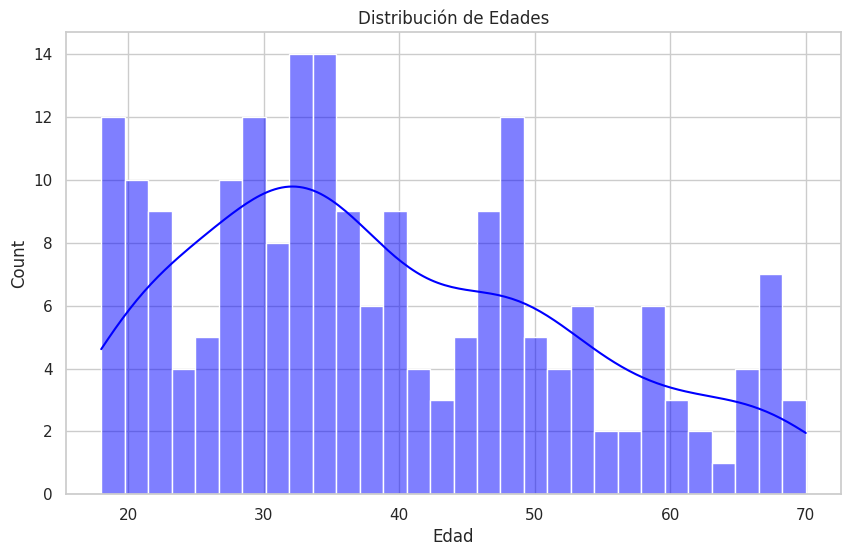

In [2]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.histplot(data=df, x="Age", kde=True, color="blue", bins=30)

plt.title("Distribución de Edades")
plt.xlabel("Edad")

plt.show()


### 2. ¿Existen diferencias significativas en los ingresos anuales entre hombres y mujeres?
- **Objetivo**: Comparar la distribución de ingresos anuales entre géneros.
- **Respuesta esperada**: Una gráfica de cajas (boxplot) que muestre la distribución de Annual Income (k$) por género.

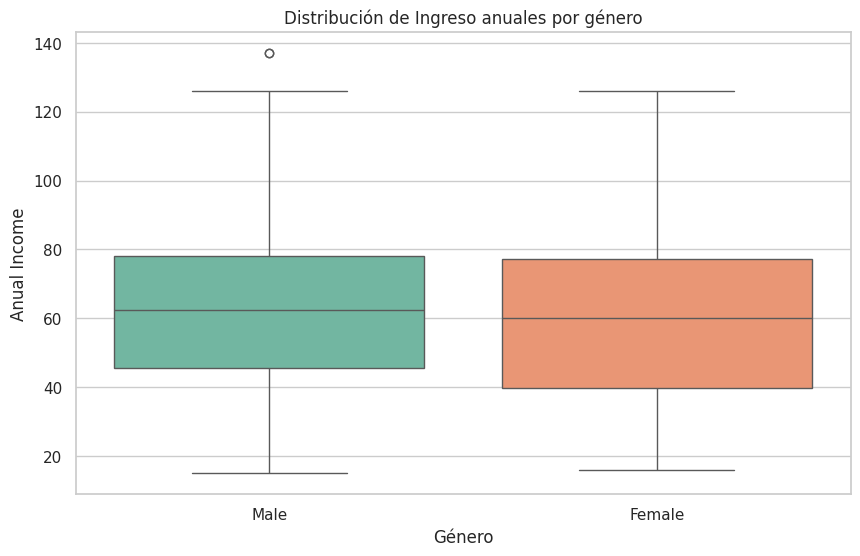

In [23]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x="Gender", y="Annual Income (k$)", palette="Set2")

plt.title("Distribución de Ingreso anuales por género")
plt.ylabel("Anual Income")
plt.xlabel("Género")

plt.show()

### 3. ¿Cómo se distribuye la puntuación de gasto (Spending Score) entre los diferentes rangos de edad?
- **Objetivo**: Analizar la relación entre la edad y la puntuación de gasto.
- **Respuesta esperada**: Una gráfica de dispersión (scatter plot) o un gráfico de cajas que compare la Spending Score (1-100) con diferentes grupos de edad.

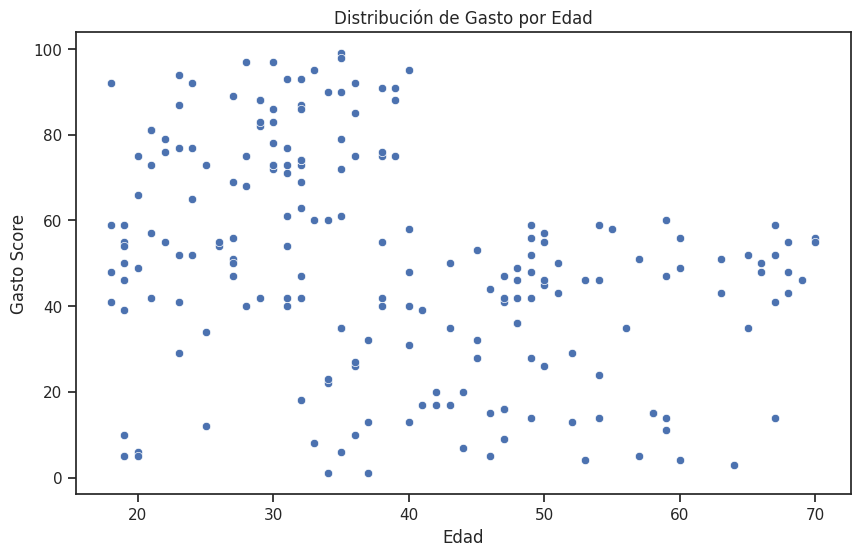

In [26]:
sns.set_theme(style="ticks")

plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x="Age", y="Spending Score (1-100)", palette="Set2")

plt.title("Distribución de Gasto por Edad")
plt.ylabel("Gasto Score")
plt.xlabel("Edad")

plt.show()

### 4. ¿Cuál es la correlación entre el ingreso anual y la puntuación de gasto?
- **Objetivo**: Identificar si existe una relación lineal entre el ingreso y el gasto.
- **Respuesta esperada**: Una gráfica de dispersión y el cálculo del coeficiente de correlación entre Annual Income (k$) y Spending Score (1-100).

El coeficiente de correlación de Pearson es: 0.01


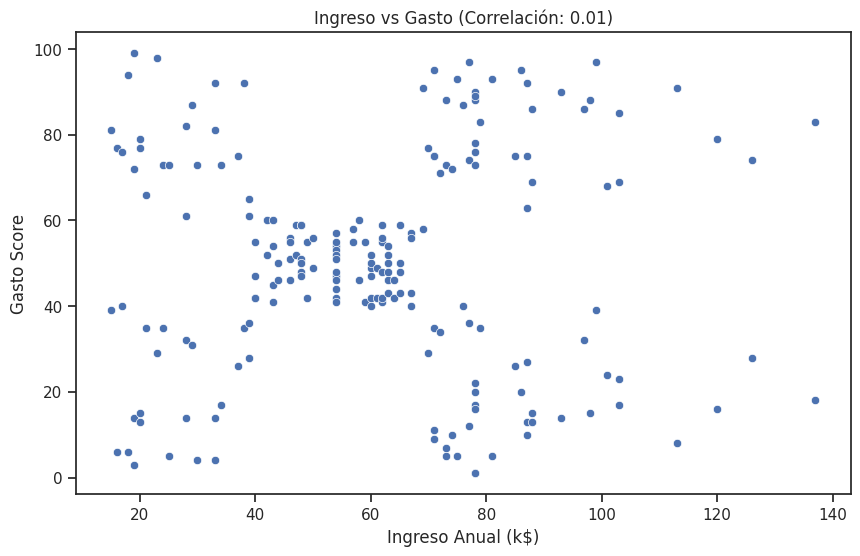

In [29]:
sns.set_theme(style="ticks")

plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x="Annual Income (k$)", y="Spending Score (1-100)")
correlacion = df['Annual Income (k$)'].corr(df['Spending Score (1-100)'])

print(f"El coeficiente de correlación de Pearson es: {correlacion:.2f}")

plt.title(f"Ingreso vs Gasto (Correlación: {correlacion:.2f})")
plt.ylabel("Gasto Score")
plt.xlabel("Ingreso Anual (k$)")

plt.show()

### 5. ¿Cómo varía la puntuación de gasto en diferentes grupos de ingresos anuales?
- **Objetivo**: Examinar cómo los clientes en diferentes rangos de ingresos se comportan en términos de gasto.
- **Respuesta esperada**: Una gráfica de cajas o de violín que muestre la Spending Score (1-100) para diferentes rangos de Annual Income (k$).

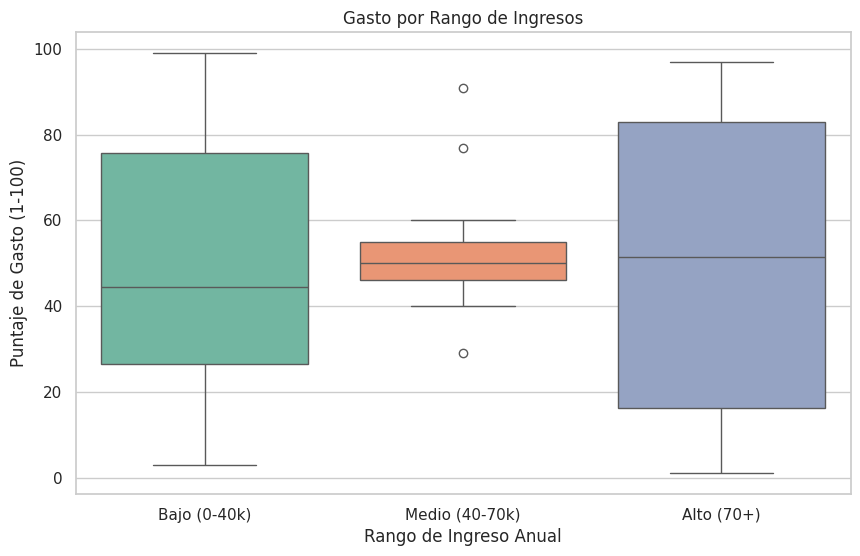

In [33]:
df['Income_Range'] = pd.cut(df['Annual Income (k$)'], 
                            bins=[0, 40, 70, 140], 
                            labels=['Bajo (0-40k)', 'Medio (40-70k)', 'Alto (70+)'])

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x="Income_Range", y="Spending Score (1-100)", palette="Set2")

# 4. Etiquetas correctas
plt.title("Gasto por Rango de Ingresos")
plt.xlabel("Rango de Ingreso Anual")
plt.ylabel("Puntaje de Gasto (1-100)")

plt.show()

### 6. ¿Cuál es la proporción de clientes por género?
- **Objetivo**: Determinar el balance de género en el conjunto de datos.
- **Respuesta esperada**: Una gráfica de barras o un gráfico de pastel que muestre la proporción de hombres y mujeres.

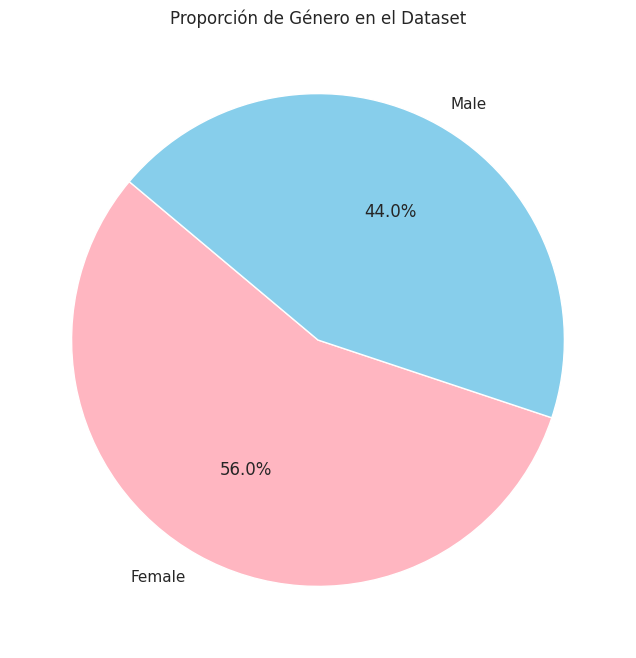

In [36]:
conteo = df['Gender'].value_counts()

plt.figure(figsize=(8, 8))

# 3. Crear la gráfica de pastel
plt.pie(conteo, 
        labels=conteo.index, 
        autopct='%1.1f%%', # Esto añade el porcentaje con un decimal
        startangle=140,    # Gira la gráfica para que se vea mejor
        colors=['lightpink', 'skyblue'])


plt.title("Proporción de Género en el Dataset")

plt.show()

### 7. ¿Qué grupos de edad gastan más en promedio?
- **Objetivo**: Identificar los grupos de edad que tienen una mayor puntuación de gasto en promedio.
- **Respuesta esperada**: Una gráfica de barras que compare la puntuación de gasto promedio entre diferentes grupos de edad.

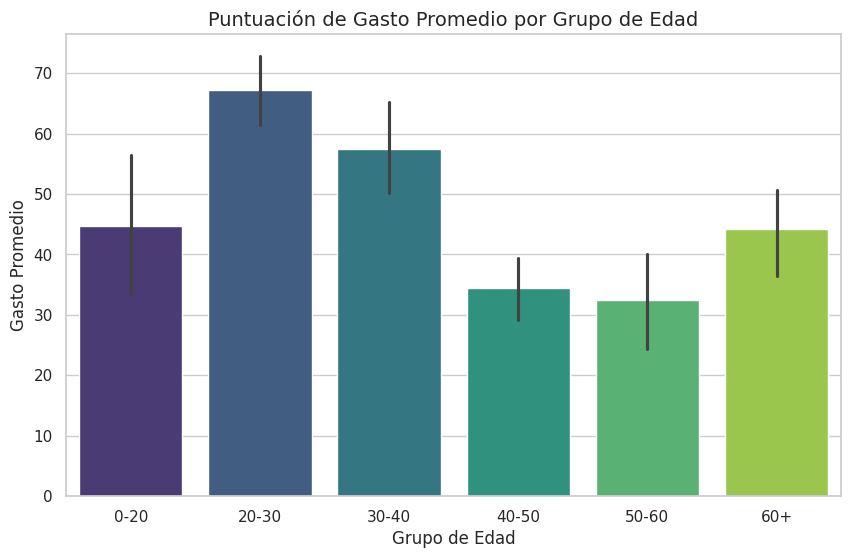

In [37]:
df['Age_Group'] = pd.cut(df['Age'], 
                         bins=[0, 20, 30, 40, 50, 60, 100], 
                         labels=['0-20', '20-30', '30-40', '40-50', '50-60', '60+'])


sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.barplot(data=df, x='Age_Group', y='Spending Score (1-100)', palette='viridis')

plt.title('Puntuación de Gasto Promedio por Grupo de Edad', fontsize=14)
plt.xlabel('Grupo de Edad')
plt.ylabel('Gasto Promedio')

plt.show()

### 8. ¿Hay alguna relación entre la edad y el ingreso anual de los clientes?
- **Objetivo**: Explorar si hay una tendencia entre la edad de los clientes y sus ingresos.
- **Respuesta esperada**: Una gráfica de dispersión que muestre la relación entre Age y Annual Income (k$).

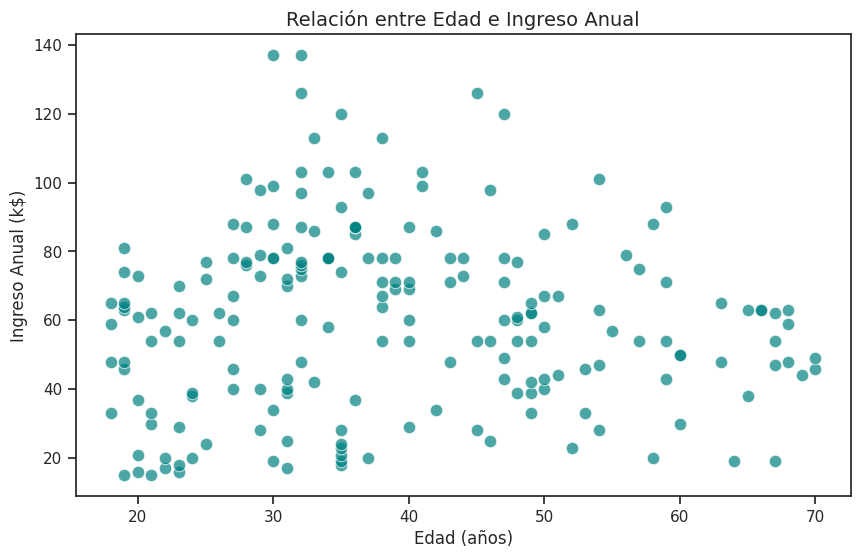

In [42]:
sns.set_theme(style="ticks")

plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x="Age", y="Annual Income (k$)", color="teal", s=80, alpha=0.7)

plt.title("Relación entre Edad e Ingreso Anual", fontsize=14)
plt.xlabel("Edad (años)")
plt.ylabel("Ingreso Anual (k$)")

plt.show()

### 9. ¿Cuál es la distribución conjunta de la edad y el ingreso anual?
- **Objetivo**: Entender cómo se distribuyen estas dos variables en conjunto.
- **Respuesta esperada**: Una gráfica de dispersión con una densidad de puntos o un gráfico de hexágonos que muestre la distribución conjunta de Age y Annual Income (k$).

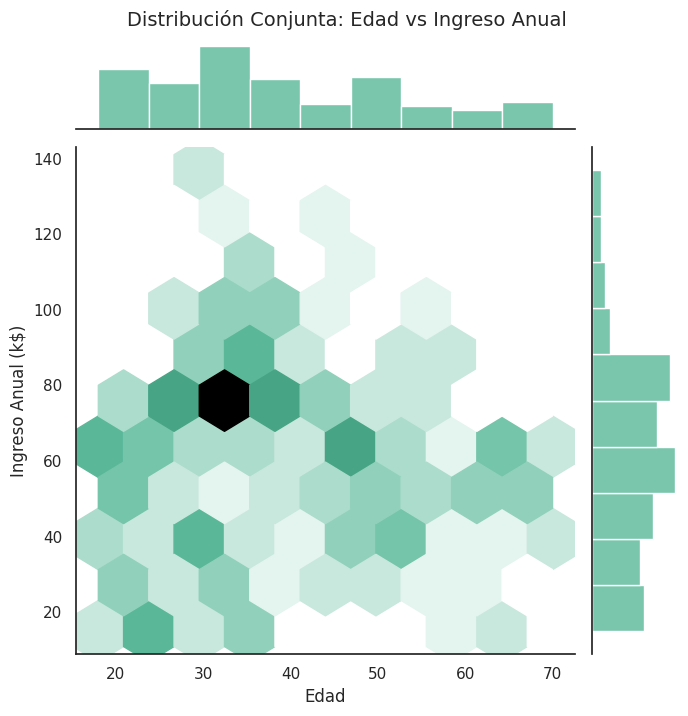

In [44]:
sns.set_theme(style="white")

# 2. Crear el Joint Plot con celdas hexagonales
# El parámetro 'kind="hex"' crea los hexágonos de densidad
g = sns.jointplot(data=df, x="Age", y="Annual Income (k$)", kind="hex", color="#4CB391", height=7)


g.fig.suptitle("Distribución Conjunta: Edad vs Ingreso Anual", y=1.02, fontsize=14)
g.set_axis_labels("Edad", "Ingreso Anual (k$)", fontsize=12)

plt.show()

### 10. ¿Cómo se distribuyen los clientes en función de la puntuación de gasto y el género?
- **Objetivo**: Analizar la relación entre la puntuación de gasto y el género.
- **Respuesta esperada**: Una gráfica de dispersión o un gráfico de violín que muestre la Spending Score (1-100) separada por género.

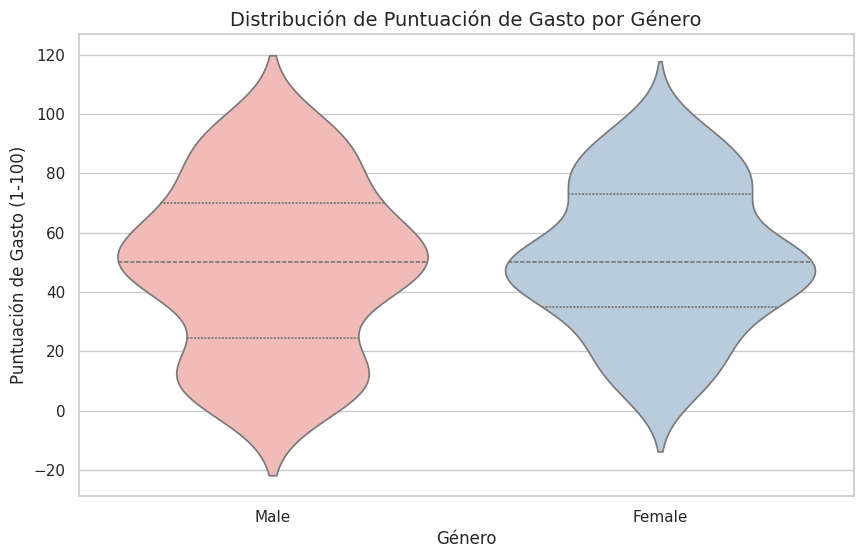

In [46]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.violinplot(data=df, x="Gender", y="Spending Score (1-100)", palette="Pastel1", inner="quartile")

plt.title("Distribución de Puntuación de Gasto por Género", fontsize=14)
plt.xlabel("Género")
plt.ylabel("Puntuación de Gasto (1-100)")

plt.show()